## Librerias y modelo

In [65]:
from ultralytics import YOLO
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.models import resnet18
import cv2
import numpy as np
from PIL import Image
model = YOLO("yolov8n.pt")


## Probar en una carpeta

In [66]:
ruta = Path("/home/tobias/Escritorio/DataYOLO/ejemplosVarios/")
for img in ruta.iterdir():
    results = model(img, classes=[16])

    results[0].show()


image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img01.png: 448x640 1 dog, 4.5ms
Speed: 1.3ms preprocess, 4.5ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img07.png: 640x448 1 dog, 5.3ms
Speed: 1.4ms preprocess, 5.3ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img09.png: 640x576 1 dog, 6.8ms
Speed: 2.3ms preprocess, 6.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)

image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img03.png: 640x448 1 dog, 6.2ms
Speed: 1.4ms preprocess, 6.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img08.png: 448x640 1 dog, 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img02.

## Detectar perro y recortarlo

In [4]:
resultados = model("/home/tobias/Escritorio/DataYOLO/ejemplosVarios/img02.png", classes=[16])

imagen = resultados[0].orig_img

for i, caja in enumerate(resultados[0].boxes.xyxy):
    x1, y1, x2, y2 = map(int, caja)
    recorte = imagen[y1:y2, x1:x2]
    cv2.imwrite(f"perro_{i}.jpg", recorte)


image 1/1 /home/tobias/Escritorio/DataYOLO/ejemplosVarios/img02.png: 640x640 5 dogs, 4.2ms
Speed: 13.7ms preprocess, 4.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


## Funcion a implementar detect_dogs()

In [ ]:
def detect_dogs(image: np.ndarray) -> list[tuple[tuple[int, int, int, int], float]]:
    
    resultados = model(image, classes=[16], verbose=False)
    
    perros_detectados = []
    
    # Extraemos las cajas 
    cajas = resultados[0].boxes
    
    # Iteramos sobre las detecciones
    for i in range(len(cajas)):
        # Extraemos coordenadas y las convertimos a enteros
        x1, y1, x2, y2 = map(int, cajas.xyxy[i].tolist())
        
        # Extraemos la confianza y la convertimos a float 
        confianza = float(cajas.conf[i].item())
        
        # Armamos la estructura requerida: ((x1, y1, x2, y2), confianza)
        tupla_perro = ((x1, y1, x2, y2), confianza)
        
        # Lo agregamos a nuestra lista 
        perros_detectados.append(tupla_perro)
        
    return perros_detectados

In [ ]:
ruta_imagen = "/home/tobias/Escritorio/DataYOLO/ejemplosVarios/img02.png"
imagen = cv2.imread(ruta_imagen)

detecciones = detect_dogs(imagen)

print("Resultado", detecciones)

for (x1, y1, x2, y2), confianza in detecciones:
    print(f"Perro encontrado con confianza de {confianza:.2f}")
    print(f"Coordenadas: x1={x1}, y1={y1}, x2={x2}, y2={y2}")
    
    # para recortar la img
    recorte = imagen[y1:y2, x1:x2]
    cv2.imwrite(f"perro_{confianza}.jpg", recorte)

Resultado [((775, 504, 1023, 1008), 0.8908848166465759), ((611, 724, 788, 972), 0.8229305148124695), ((110, 762, 458, 1011), 0.8088074326515198), ((358, 473, 602, 981), 0.6466386914253235), ((771, 710, 883, 954), 0.44136732816696167)]
Perro encontrado con confianza de 0.89
Coordenadas: x1=775, y1=504, x2=1023, y2=1008
Perro encontrado con confianza de 0.82
Coordenadas: x1=611, y1=724, x2=788, y2=972
Perro encontrado con confianza de 0.81
Coordenadas: x1=110, y1=762, x2=458, y2=1011
Perro encontrado con confianza de 0.65
Coordenadas: x1=358, y1=473, x2=602, y2=981
Perro encontrado con confianza de 0.44
Coordenadas: x1=771, y1=710, x2=883, y2=954


In [70]:
def recortar_crop(img,detecciones):
    for (x1, y1, x2, y2), confianza in detecciones:
    
        print(f"Perro encontrado con confianza de {confianza:.2f}")
        print(f"Coordenadas: x1={x1}, y1={y1}, x2={x2}, y2={y2}")
    
    # para recortar la img
    recorte = img[y1:y2, x1:x2]
    return recorte

## Funcion a implementar classify_detected_dog()

In [94]:
clases = [
    "Afghan", "African Wild Dog", "Airedale", "American Hairless", "American Spaniel",
    "Basenji", "Basset", "Beagle", "Bearded Collie", "Bermaise",
    "Bichon Frise", "Blenheim", "Bloodhound", "Bluetick", "Border Collie",
    "Borzoi", "Boston Terrier", "Boxer", "Bull Mastiff", "Bull Terrier",
    "Bulldog", "Cairn", "Chihuahua", "Chinese Crested", "Chow",
    "Clumber", "Cockapoo", "Cocker", "Collie", "Corgi",
    "Coyote", "Dalmation", "Dhole", "Dingo", "Doberman",
    "Elk Hound", "French Bulldog", "German Sheperd", "Golden Retriever", "Great Dane",
    "Great Perenees", "Greyhound", "Groenendael", "Irish Spaniel", "Irish Wolfhound",
    "Japanese Spaniel", "Komondor", "Labradoodle", "Labrador", "Lhasa",
    "Malinois", "Maltese", "Mex Hairless", "Newfoundland", "Pekinese",
    "Pit Bull", "Pomeranian", "Poodle", "Pug", "Rhodesian",
    "Rottweiler", "Saint Bernard", "Schnauzer", "Scotch Terrier", "Shar_Pei",
    "Shiba Inu", "Shih-Tzu", "Siberian Husky", "Vizsla", "Yorkie",
]

def classify_detected_dog(crop: np.ndarray) -> tuple[str, float]:

    # Instanciamos el modelo y adaptamos a nuestra estructura
    model = resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 70)
    model.load_state_dict(torch.load('models/resnet18_finetuned.pth', map_location='cuda'))
    model.eval()

    # Preprocesamiento igual que en valid/test
    preprocess = transforms.Compose([
        transforms.Resize(224),
        # transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Convertir BGR (OpenCV) a RGB y pasar a PIL y luego a tensor
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)
    input_tensor = preprocess(pil_img).unsqueeze(0) # Se aplica el prepro y se agrega la dim

    # Lo mandamos a gpu
    model.to('cuda')
    input_tensor = input_tensor.to('cuda')

    # Predecimos
    with torch.no_grad():
        output = model(input_tensor)
        probabilidades = torch.nn.functional.softmax(output[0], dim=0)
    
    
    top_prob, top_cat = torch.max(probabilidades, 0)
    

    nombre_clase = clases[top_cat.item()]
    
    print(f"Predicción: {nombre_clase} con probabilidad {top_prob.item():.2f}")

    return (nombre_clase, round(top_prob.item(),2))

img = cv2.imread("/home/tobias/Escritorio/DataYOLO/ejemplosVarios/img06.png")
classify_detected_dog(img)

Predicción: Rhodesian con probabilidad 0.25


('Rhodesian', 0.25)

## Flujo completo Deteccion -> Crop -> Clasificacion

Perro encontrado con confianza de 0.77
Coordenadas: x1=174, y1=534, x2=1200, y2=1595
Predicción: Yorkie con probabilidad 1.00


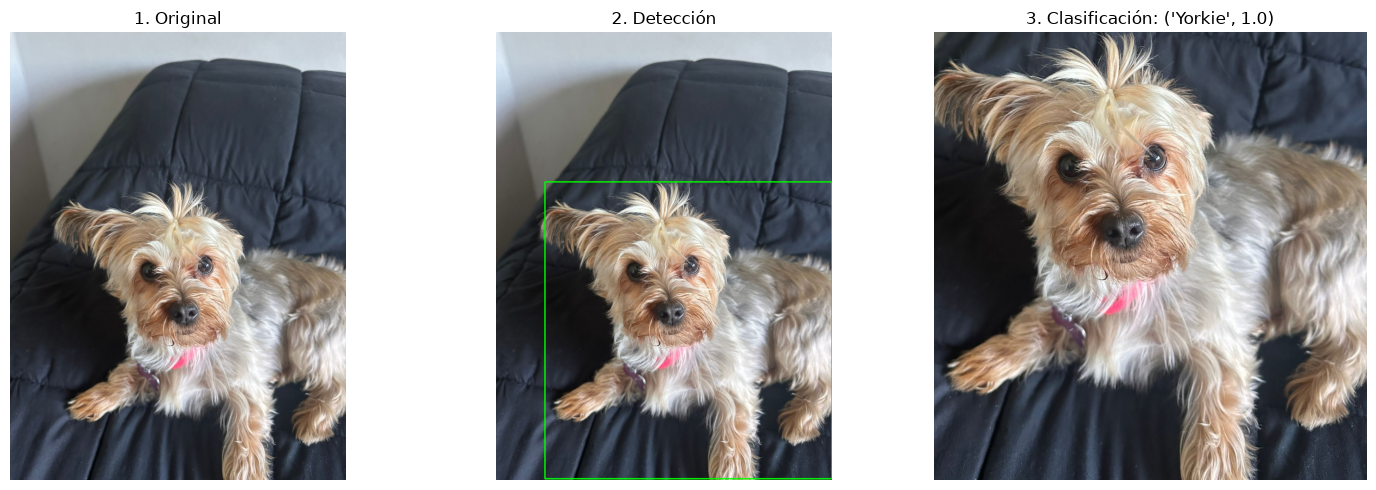

In [107]:
img_ejemplo = cv2.imread("data/dataset_propio/sami/img3.jpeg")

coordenadas = detect_dogs(img_ejemplo)

crop = recortar_crop(img_ejemplo, coordenadas)

clasificacion = classify_detected_dog(crop)

img_rgb = cv2.cvtColor(img_ejemplo, cv2.COLOR_BGR2RGB)
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

img_bbox = img_rgb.copy()
if coordenadas:
    (x1, y1, x2, y2), conf = coordenadas[0] 
    cv2.rectangle(img_bbox, (x1, y1), (x2, y2), (0, 255, 0), 3)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img_rgb)
axs[0].set_title("1. Original")
axs[0].axis('off')

axs[1].imshow(img_bbox)
axs[1].set_title("2. Detección")
axs[1].axis('off')

axs[2].imshow(crop_rgb)
axs[2].set_title(f"3. Clasificación: {clasificacion}")
axs[2].axis('off')

plt.tight_layout()
plt.show()